In [1]:
using LinearAlgebra
using QuantumToolbox
using GLMakie
using Plots

## 1. Inital Testing 

Basis, probability vectors, gates interacting with states

In [3]:
Zero = basis(2,0)
One = basis(2,1)
theta = pi/2
phi = pi/4
Px = cos(theta/2)Zero+One*sin(theta/2)*exp(im*phi)
sigmay()*sigmaz()*Zero


Quantum Object:   type=Ket()   dims=([2], [1])   size=(2,)
2-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 1.0im

## 2. Gates and Bloch Sphere

Making gates, visualizing changes on the Bloch Sphere

In [ ]:
b = Bloch()
Zero = basis(2,0)
One = basis(2,1)
z0 = [0,0,1]
z1 = [0,0,-1]

X = Qobj([0 1; 1 0])
Y = Qobj([0 -im; -im 0])
Z = Qobj([1 0; 0 -1])
H = Qobj([1/sqrt(2) 1/sqrt(2); 1/sqrt(2) -1/sqrt(2)])
S = Qobj([1 0; 0 im])
T = Qobj([1 0 ; 0 exp(im*pi/64)])
rot_90 = Qobj([1/√2 -1/√2; 1/√2 1/√2])

theta = pi/2
phi = 0
Px = cos(theta/2)*Zero+sin(theta/2)*exp(im*phi)*One

#add_states!(b,Px)
add_states!(b,  rot_90^4 * Zero)

fig, _ = render(b)
fig

rot_90^4 * Zero


Quantum Object:   type=Ket()   dims=([2], [1])   size=(2,)
2-element Vector{ComplexF64}:
 -0.9999999999999996 + 0.0im
                 0.0 + 0.0im

## 3. Graphing

Basic functions, bar chart visualization, understanding collapsing qubits, initial conditions

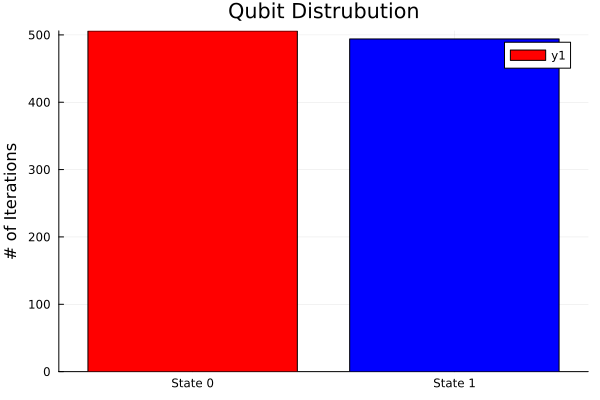

In [23]:
lst = [H,Y]
function gate(vec , lst)
    for i in lst
        vec = i * vec
    end
    return vec
end

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function count(n)
    count0 = 0
    count1 = 0
    for i in range(1,n)
        measured = measure(gate(Zero, lst))
        if measured < 1
            count0 += 1
        else
            count1 += 1
        end
        state = Zero
    end
    return [count0, count1]
end

operated = count(1000)

bar(["State 0", "State 1"], 
    [operated[1], operated[2]], 
    title = "Qubit Distrubution", 
    color = [:red, :blue], 
    ylabel = "# of Iterations")

## 4. Animation

Visualize the H, Y, and X gets happening to the 0 state

In [30]:
Begin = [0,0,1]

b = Bloch()
fig, lscene = render(b)

function Gate_Chooser(string)
    if string == "H"
        th = LinRange(pi/2, 0, 10)
        xp = cos.(th)
        yp = zeros(10)
        zp = sin.(th)
        return xp, yp, zp
    end
    if string == "Y"
        th = LinRange(pi/2, -pi/2, 10)
        xp = cos.(th)
        yp = zeros(10)
        zp = sin.(th)
        return xp, yp, zp
    end
     if string == "X"
        th = LinRange(pi/2, -pi/2, 10)
        xp = zeros(10)
        yp = cos.(th)
        zp = sin.(th)
        return xp, yp, zp
    end
end

record(fig, "Vector_sim.mp4", eachindex(tlist), framerate = 20) do idx
    clear!(b)
    add_vectors!(b, Begin)
    Gate = Gate_Chooser("X")
    xp = Gate[1]
    yp = Gate[2]
    zp = Gate[3]
    add_vectors!(b, [xp[idx], yp[idx], zp[idx]])
    render(b, location = lscene)
end

"Vector_sim.mp4"